In [24]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
from uncertainties import ufloat
import uncertainties
from uncertainties.umath import *
pd.set_option('future.no_silent_downcasting', True)
from statannotations.Annotator import Annotator


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [25]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [26]:
folder = Path('../../data/5_interactions/')
df = pd.read_csv(folder / 'all_interactions_cfus.csv')

In [27]:
tab10 = sns.color_palette('tab10')
species_palette = {
    'At': tab10[2],
    'Ct': tab10[1],
    'Oa': tab10[3],
    'Ml': tab10[0]
    
}

# Quantify interactions

In [28]:
df.reset_index(drop=True)
df['Is coculture'] = ['+' in x for x in df['Inoculated species']]
 

In [29]:
df.Medium.unique()

array(['Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No CS', 'At_mannose',
       'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At_malate', 'Ct_malate', 'Ml_malate',
       'Oa_malate', 'M9_malate', 'M9_malate+thiamine',
       'M9_malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [30]:

four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in df.Medium.unique():
    if medium == 'No CS':
        continue
    dfm = df.loc[df.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
interactions_df = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])


In [31]:
from statsmodels.stats.multitest import multipletests

# Perform multiple test correction using the Benjamini-Hochberg procedure
pvalues = interactions_df['T-test pvalue']
corrected_pvalues = multipletests(pvalues, method='fdr_bh')[1]  # [1] gives the adjusted p-values

# Add the corrected p-values to the DataFrame
interactions_df['Corrected pvalue'] = corrected_pvalues

In [32]:
interactions_df['log10 pval'] = np.log10(interactions_df['T-test pvalue'])
interactions_df['log10 adj. pval'] = np.log10(interactions_df['Corrected pvalue'])

In [33]:
interactions_df.head()

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval
0,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230,0.237933,-0.834964,-0.623545
1,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410,0.509663,-0.377361,-0.292717
2,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121,0.000892,-3.918152,-3.049824
3,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636,0.095207,-1.360151,-1.021333
4,Ct,Oa,Ml_mannose,-0.121352,0.135099,0.157224,0.251558,-0.803482,-0.599362


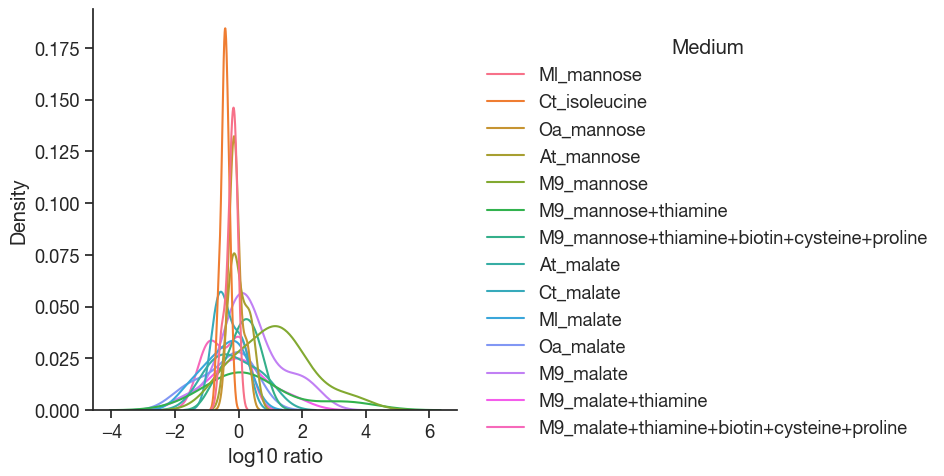

In [34]:
ax = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Medium', kind = 'kde')


In [35]:
interactions_df['Fresh'] = ['Fresh' if x.split('_')[0]=='M9' else 'Spent' for x in interactions_df.Medium]

In [36]:
interactions_df.to_csv(folder / 'all_interactions_cfus_with_stats.csv', index=False)

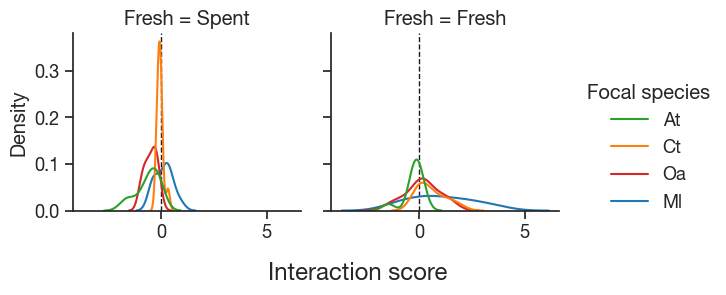

In [37]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Focal species', palette=species_palette, fill = False, 
                kind = 'kde', col='Fresh', aspect=1, height=3)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_species.pdf')



In [38]:
interactions_df.loc[(interactions_df['Focal species']=='Ml')&(interactions_df['Fresh']=='Fresh')].sort_values('log10 ratio')

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval,Fresh
93,Ml,Ct,M9_malate+thiamine+biotin+cysteine+proline,-1.069081,0.267553,0.002531,0.011045,-2.596692,-1.956844,Fresh
91,Ml,At,M9_malate+thiamine+biotin+cysteine+proline,-0.888026,0.230853,0.003270,0.013080,-2.485463,-1.883403,Fresh
94,Ml,Oa,M9_malate+thiamine+biotin+cysteine+proline,-0.791116,0.167765,0.003785,0.014534,-2.421943,-1.837612,Fresh
43,Ml,At,M9_mannose+thiamine+biotin+cysteine+proline,0.126465,0.178663,0.202884,0.282274,-0.692751,-0.549329,Fresh
45,Ml,Ct,M9_mannose+thiamine+biotin+cysteine+proline,0.169931,0.161532,0.066766,0.137961,-1.175445,-0.860243,Fresh
82,Ml,Oa,M9_malate,0.516993,0.381152,0.178752,0.272384,-0.747749,-0.564818,Fresh
46,Ml,Oa,M9_mannose+thiamine+biotin+cysteine+proline,0.546682,0.206512,0.007869,0.025179,-2.104106,-1.598956,Fresh
31,Ml,Ct,M9_mannose,0.831596,0.396524,0.000025,0.000301,-4.601019,-3.521838,Fresh
88,Ml,Oa,M9_malate+thiamine,1.524546,0.387053,0.000003,0.000057,-5.492898,-4.240815,Fresh
79,Ml,Ct,M9_malate,1.922486,0.210485,0.000055,0.000588,-4.258980,-3.230951,Fresh


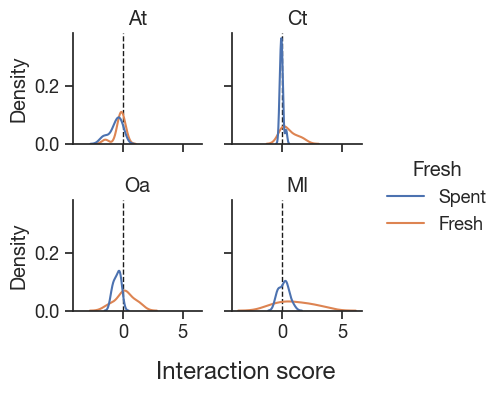

In [39]:
g = sns.displot(data = interactions_df, x = 'log10 ratio', hue = 'Fresh', fill = False, 
                kind = 'kde', col='Focal species', aspect=1, height=2, col_wrap=2)#, alpha = 0.5)
for ax in g.axes.flat:
     ax.axvline(0, ls = '--', c = 'k', zorder=0, lw=1)
     ax.set_xlabel('')
g.fig.supxlabel('Interaction score')
g.set_titles("{col_name}")
plt.savefig(figure_folder / f'interaction_distribution_species_fresh_spent.pdf')

In [40]:
interactions_df.groupby(['Focal species', 'Fresh']).agg({'log10 ratio': ['mean', 'std']}).reset_index().rename(columns = {'mean': 'Mean', 'std': 'Std'})

Focal species  Fresh log10 ratio          
                              Mean       Std
0            At  Fresh   -0.263211  0.461146
1            At  Spent   -0.634563  0.550048
2            Ct  Fresh    0.550945  0.660144
3            Ct  Spent   -0.058949  0.145235
4            Ml  Fresh    1.009850  1.486216
5            Ml  Spent    0.114141  0.412144
6            Oa  Fresh    0.143859  0.801051
7            Oa  Spent   -0.506000  0.294736

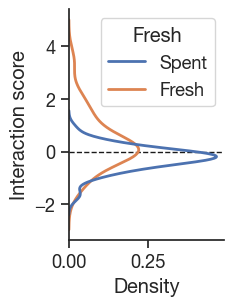

In [41]:
fig, ax = plt.subplots(figsize = (2, 3))
ax = sns.kdeplot(data = interactions_df, y = 'log10 ratio', hue = 'Fresh', lw=2)
ax.axhline(0, ls = '--', c = 'k', zorder=0, lw = 1)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_fresh_spent.pdf')

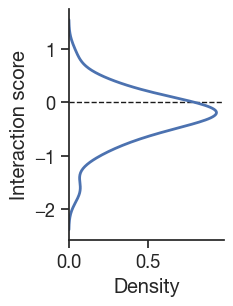

In [42]:
fig, ax = plt.subplots(figsize = (2, 3))
ax = sns.kdeplot(data = interactions_df.loc[interactions_df.Fresh=='Spent'], y = 'log10 ratio',lw=2)
ax.axhline(0, ls = '--', c = 'k', zorder=0, lw = 1)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_distribution_fresh_spent.pdf')

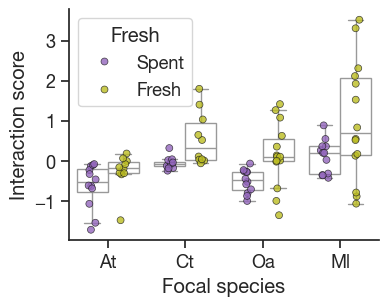

In [74]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Focal species', hue = 'Fresh',dodge=True, palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_focal_species.pdf', bbox_inches='tight')


In [46]:
interactions_df.groupby(['Focal species', 'Fresh'])['log10 ratio'].describe()

count      mean       std       min       25%       50%  \
Focal species Fresh                                                            
At            Fresh   10.0 -0.263211  0.461146 -1.482550 -0.307321 -0.178861   
              Spent   12.0 -0.634563  0.550048 -1.720159 -0.784422 -0.540241   
Ct            Fresh   10.0  0.550945  0.660144 -0.063052  0.031094  0.313411   
              Spent   12.0 -0.058949  0.145235 -0.246672 -0.138837 -0.068987   
Ml            Fresh   14.0  1.009850  1.486216 -1.069081  0.137332  0.689139   
              Spent   12.0  0.114141  0.412144 -0.424356 -0.327103  0.197489   
Oa            Fresh   14.0  0.143859  0.801051 -1.357511 -0.016289  0.104082   
              Spent   12.0 -0.506000  0.294736 -1.002333 -0.734665 -0.486325   

                          75%       max  
Focal species Fresh                      
At            Fresh -0.024815  0.182082  
              Spent -0.205769 -0.081670  
Ct            Fresh  0.934886  1.796470  
              Spent -0.026679  0.317629  
Ml            Fresh  2.065597  3.518984  
              Spent  0.361334  0.883907  
Oa            Fresh  0.555499  1.414675  
              Spent -0.271247 -0.068265

In [47]:

# Test for each combination of Fresh and Focal species
results = []
for fresh in interactions_df['Fresh'].unique():
    for species in interactions_df['Focal species'].unique():
        data = interactions_df.loc[(interactions_df['Fresh'] == fresh) & 
                                   (interactions_df['Focal species'] == species), 'log10 ratio'].dropna()
        
        if len(data) > 0:
            t_stat, p_value = st.ttest_1samp(data, popmean=0)
            results.append({
                'Fresh': fresh,
                'Focal species': species,
                'N': len(data),
                'Mean': data.mean(),
                'Std': data.std(),
                't-statistic': t_stat,
                'p-value': p_value
            })

results_df = pd.DataFrame(results)
print(results_df)

   Fresh Focal species   N      Mean       Std  t-statistic   p-value
0  Spent            At  12 -0.634563  0.550048    -3.996359  0.002099
1  Spent            Ct  12 -0.058949  0.145235    -1.406041  0.187326
2  Spent            Oa  12 -0.506000  0.294736    -5.947137  0.000096
3  Spent            Ml  12  0.114141  0.412144     0.959363  0.357989
4  Fresh            At  10 -0.263211  0.461146    -1.804957  0.104567
5  Fresh            Ct  10  0.550945  0.660144     2.639184  0.026950
6  Fresh            Oa  14  0.143859  0.801051     0.671956  0.513377
7  Fresh            Ml  14  1.009850  1.486216     2.542371  0.024544


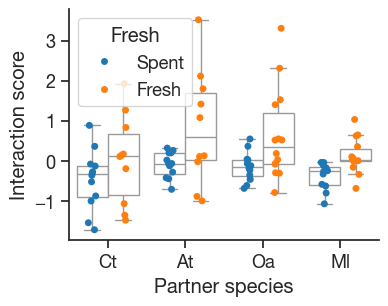

In [59]:
fig, ax = plt.subplots(1, figsize=(4,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Partner species', hue = 'Fresh',dodge=True, palette='tab10')# palette=species_palette)
sns.despine()
ax.set_ylabel('Interaction score')
plt.savefig(figure_folder / f'interaction_boxplots_partner_species.pdf', bbox_inches='tight')




In [49]:

groups = [group['log10 ratio'].values for name, group in interactions_df.groupby('Fresh')]

# Perform one-way ANOVA
f_stat, p_value = st.kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 15.253919673539542
P-value: 9.398151256311726e-05


Spent: t-statistic = -3.89430192976858, p-value = 0.0003101768220518331, mean -0.271
Fresh: t-statistic = 2.5709300657537755, p-value = 0.013368794310377338, mean 0.396


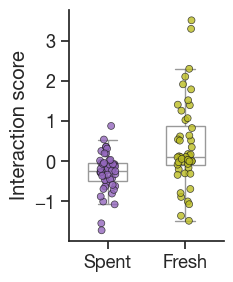

In [75]:
fig, ax = plt.subplots(1, figsize=(2,3))
ax = sns.boxplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', color = 'w', fliersize=0, 
                 hue = 'Fresh', palette={'Spent':'w', 'Fresh':'w'}, legend=False, width=0.5)
sns.stripplot(data = interactions_df, y = 'log10 ratio', x = 'Fresh', hue = 'Fresh', palette=[tab10[4], tab10[8]], edgecolor='k', linewidth=0.5, alpha=0.8) 
sns.despine()
ax.set_ylabel('Interaction score')
plt.xlabel('')

# pairs = [['Spent', 'Fresh']]

# annotator = Annotator(
#     ax, pairs, data=interactions_df, y = 'log10 ratio', x = 'Fresh' #orient="h" 
# )
# # plt.ylim(0,2)
# annotator.configure(text_format="star", loc="inside",
#     hide_non_significant=True, alpha=0.05)
# annotator.set_pvalues_and_annotate([p_value])

# Perform a one-sample t-test for each group
spent_data = interactions_df.loc[interactions_df['Fresh'] == 'Spent', 'log10 ratio']
fresh_data = interactions_df.loc[interactions_df['Fresh'] == 'Fresh', 'log10 ratio']

# Test if the mean of 'Spent' is different from 0
t_stat_spent, p_value_spent = st.ttest_1samp(spent_data, 0)

# Test if the mean of 'Fresh' is different from 0
t_stat_fresh, p_value_fresh = st.ttest_1samp(fresh_data, 0)

# Print the results
print(f"Spent: t-statistic = {t_stat_spent}, p-value = {p_value_spent}, mean {spent_data.mean():.3f}")
print(f"Fresh: t-statistic = {t_stat_fresh}, p-value = {p_value_fresh}, mean {fresh_data.mean():.3f}")
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'interaction_boxplot_fresh_spent.png', bbox_inches='tight', dpi=300)

In [51]:
interactions_df['Significance'] = interactions_df['Corrected pvalue']<0.05
interactions_df.groupby('Fresh').agg({'Significance':'sum'})

,Significance
Fresh,
Fresh,23
Spent,7


In [52]:
interactions_df['abs log10 ratio'] = np.abs(interactions_df['log10 ratio'])
interactions_df[['abs log10 ratio', 'Fresh']].groupby('Fresh').agg(['mean', 'median', 'std'])

abs log10 ratio                    
                 mean    median       std
Fresh                                    
Fresh        0.761269  0.518039  0.842620
Spent        0.404815  0.299955  0.375321

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77958/621205132.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


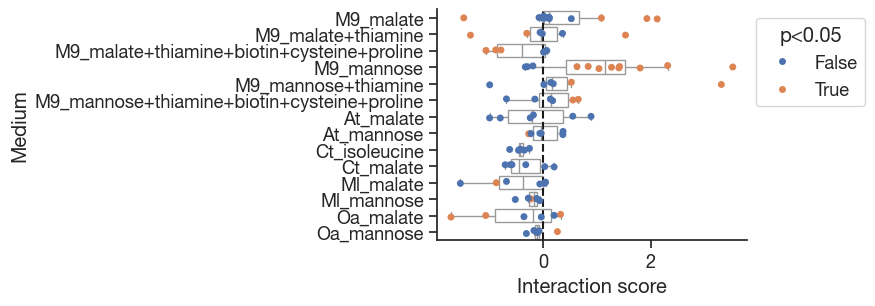

In [53]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df.sort_values(by=['Fresh','Medium']), x = 'log10 ratio', y = 'Medium', hue = 'Significance', ax=ax)# palette='copper', 
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w', fliersize=0)
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
sns.move_legend(ax, title='p<0.05', loc='upper left', bbox_to_anchor=(1, 1))
sns.despine()
plt.xlabel('Interaction score')
plt.savefig(figure_folder/'Interactions_per_medium.pdf')

In [151]:
for i, row in interactions_df.iterrows():
    cs = row['Medium'].split('+')[0].split('_')[1]
    interactions_df.at[i, 'CS'] = cs.capitalize()

In [155]:
row

Focal species                 At
Partner species               Ct
Medium                Ml_mannose
log10 ratio            -0.130848
log10 ratio std         0.149839
T-test pvalue            0.14623
Corrected pvalue        0.237933
log10 pval             -0.834964
log10 adj. pval        -0.623545
Fresh                      Spent
Significance               False
abs log10 ratio         0.130848
Significance annot              
CS                       Mannose
Name: 0, dtype: object

Ml_mannose Oa At *** -0.23074246277633886


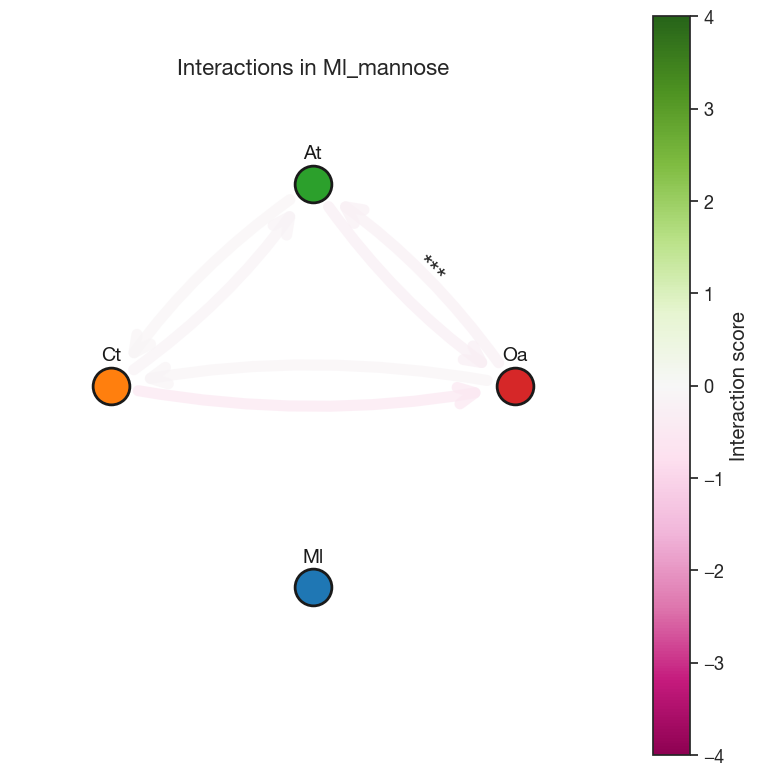

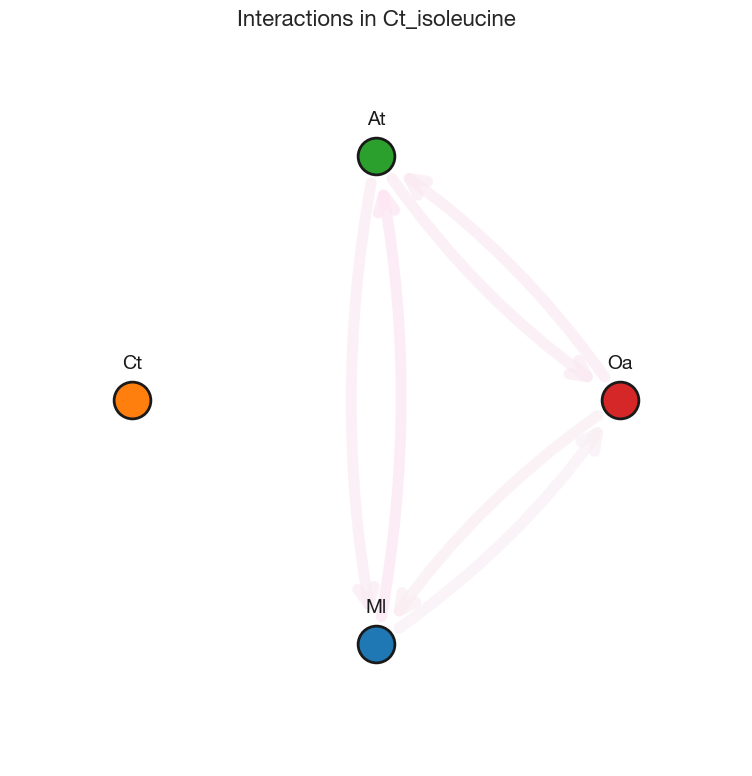

Oa_mannose At Ml * 0.25892864380202796


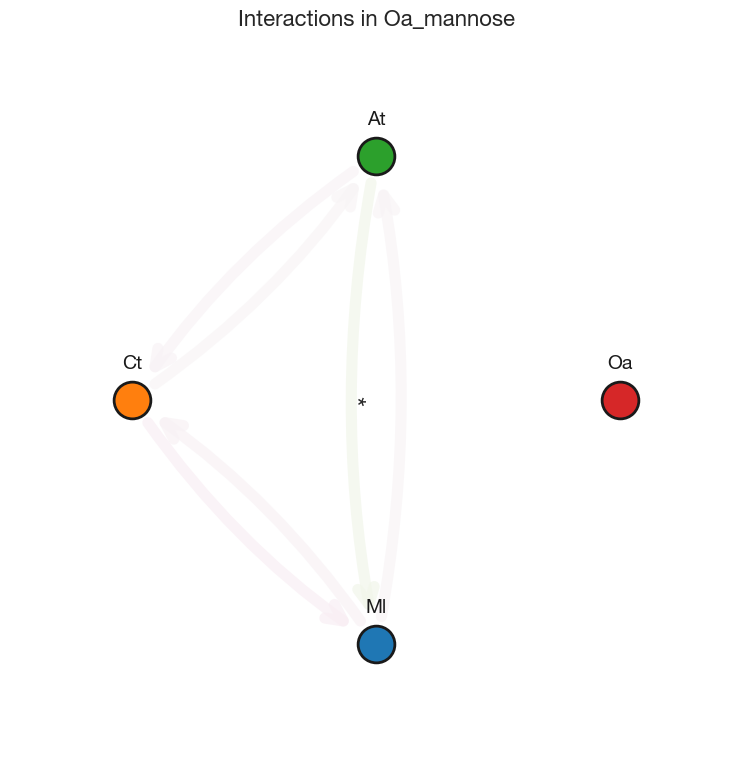

At_mannose Ct Oa * -0.27457439739222794


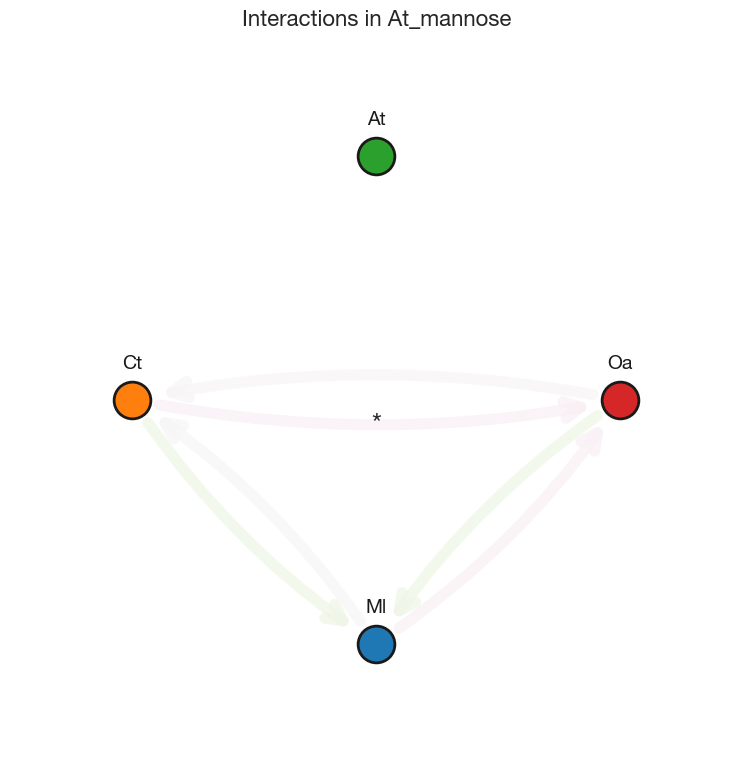

M9_mannose At Ct *** 1.7964704925973791
M9_mannose At Ml *** 3.5189837013968135
M9_mannose At Oa *** 1.4146749663157256
M9_mannose Ml Ct *** 1.0313397522062466
M9_mannose Ct Ml *** 0.8315955696106098
M9_mannose Oa Ct *** 1.400884389318819
M9_mannose Ct Oa *** 1.2646491976989718
M9_mannose Oa Ml ** 2.308716824330272
M9_mannose Ml Oa * 0.6228798352655358


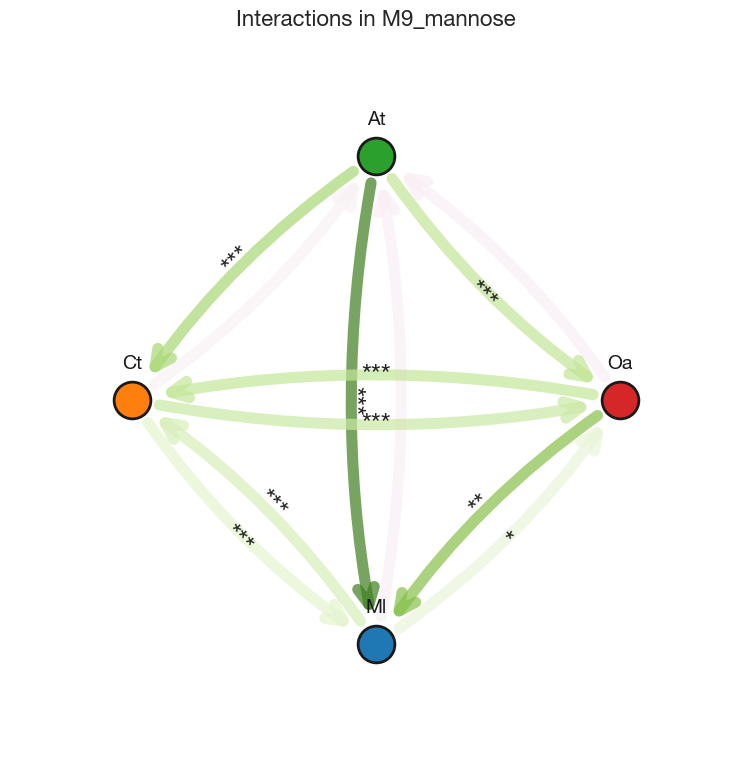

M9_mannose+thiamine Oa Ct ** 0.5190857562631985
M9_mannose+thiamine Oa Ml ** 3.3064250275506875


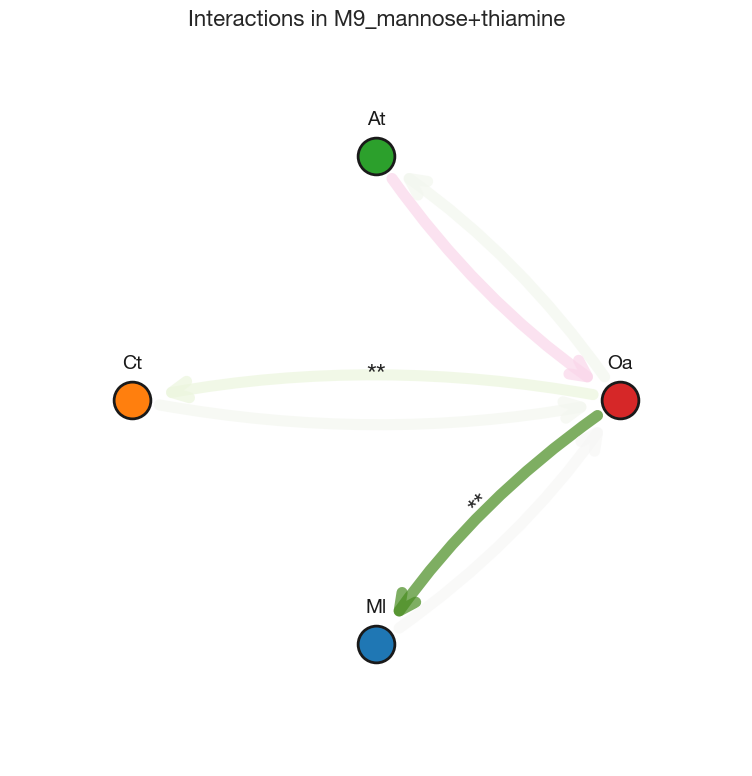

M9_mannose+thiamine+biotin+cysteine+proline Ml Ct ** 0.6455256851090527
M9_mannose+thiamine+biotin+cysteine+proline Oa Ml * 0.5466816599529624


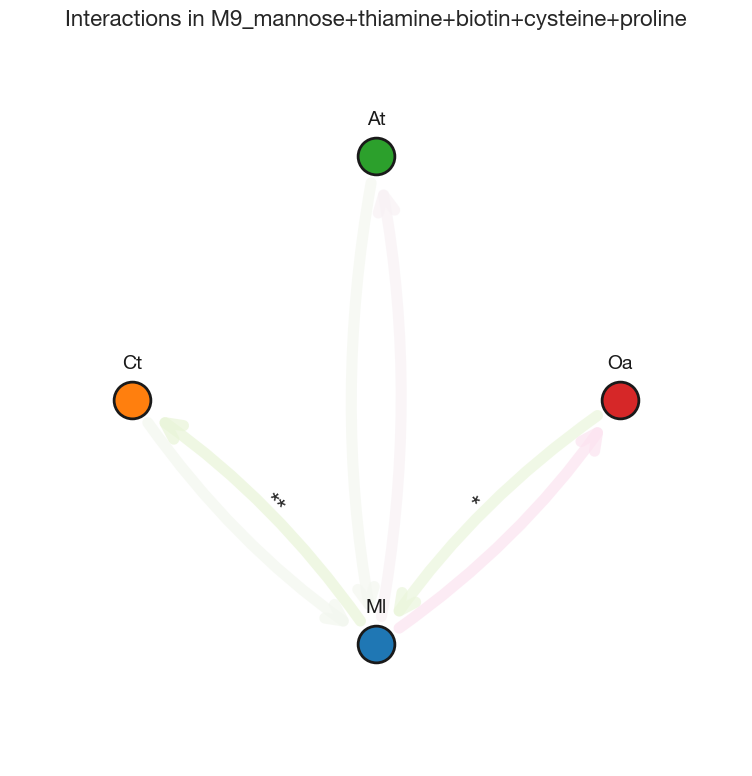

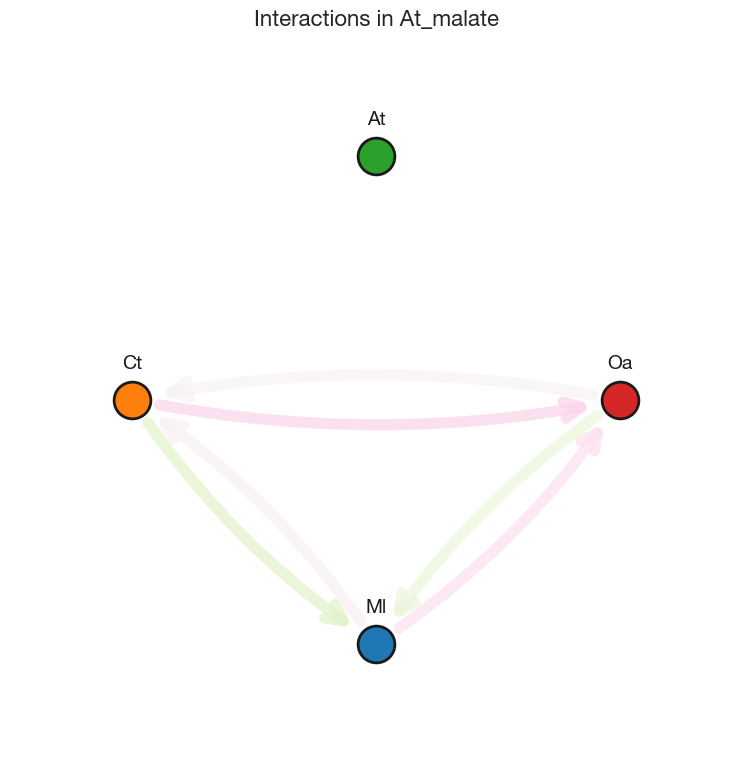

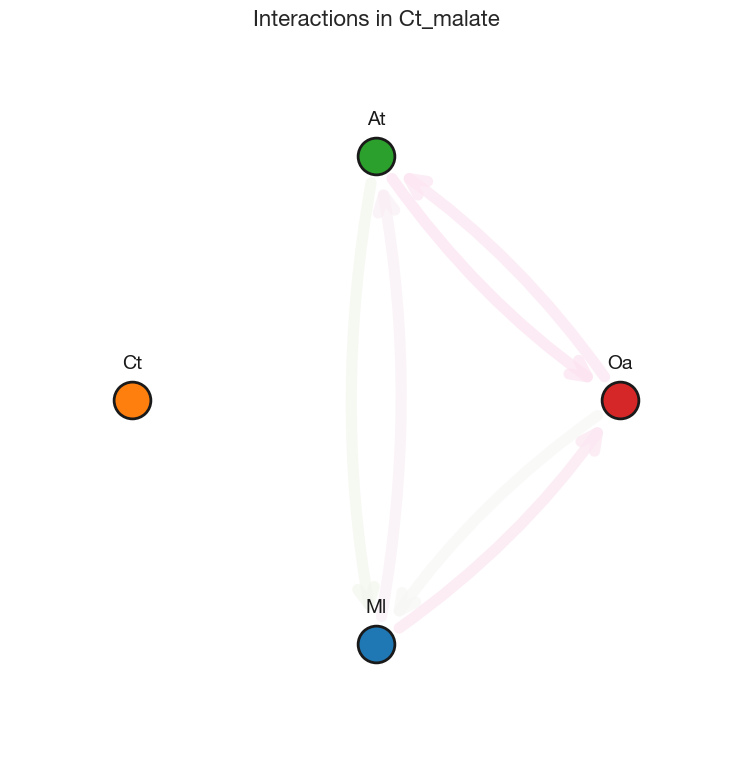

Ml_malate Ct Oa *** -0.8770398293737879


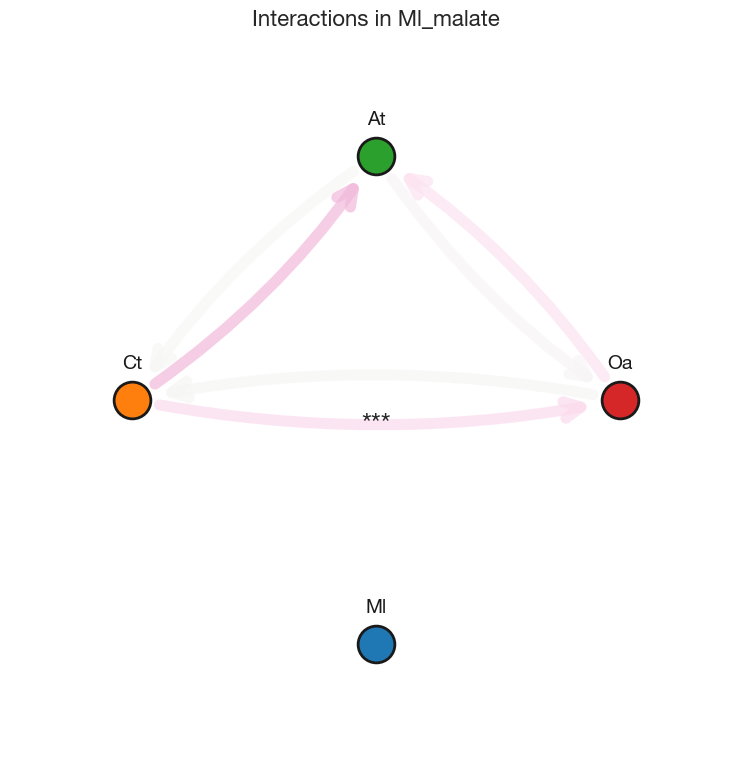

Oa_malate Ct At *** -1.7201593034059568
Oa_malate At Ct ** 0.3176292574834429
Oa_malate Ml At ** -1.0730209373428063


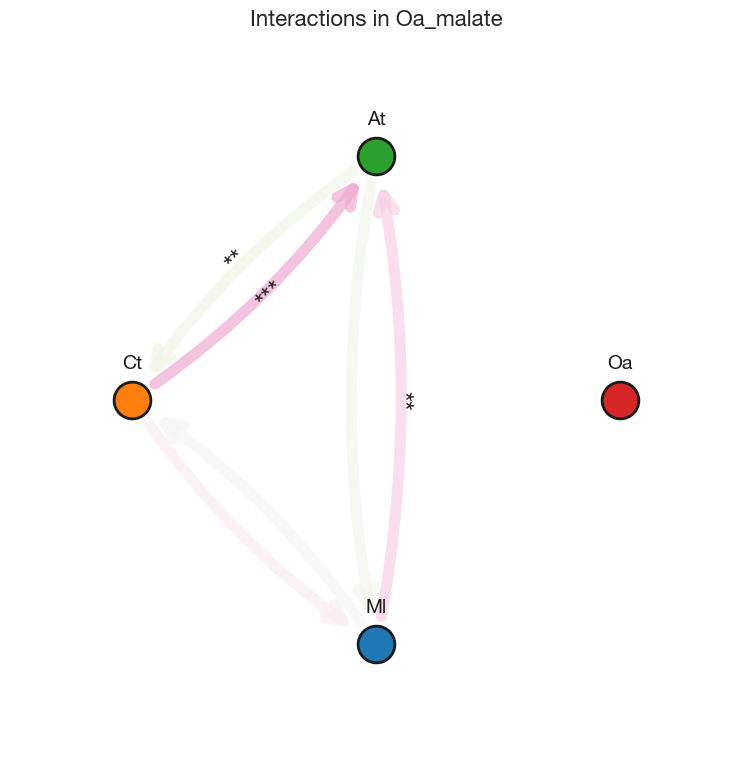

M9_malate Ct At ** -1.4825500064310606
M9_malate At Ml * 2.113300429196226
M9_malate At Oa * 1.0771659548122994
M9_malate Ct Ml *** 1.9224859133198382


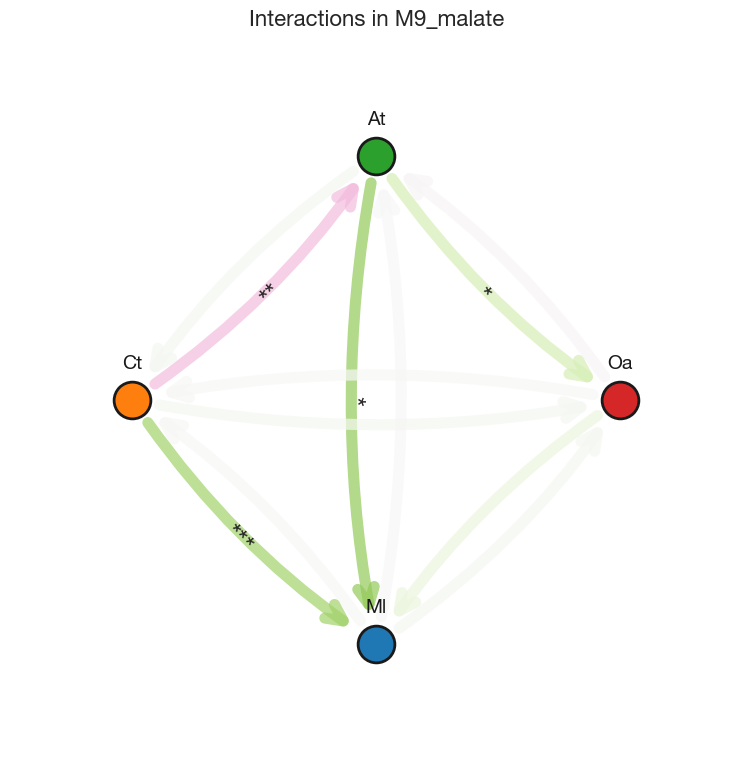

M9_malate+thiamine Oa At * -0.30998483831690765
M9_malate+thiamine Ct Oa *** -1.3575113516164294
M9_malate+thiamine Oa Ml *** 1.5245459046478005


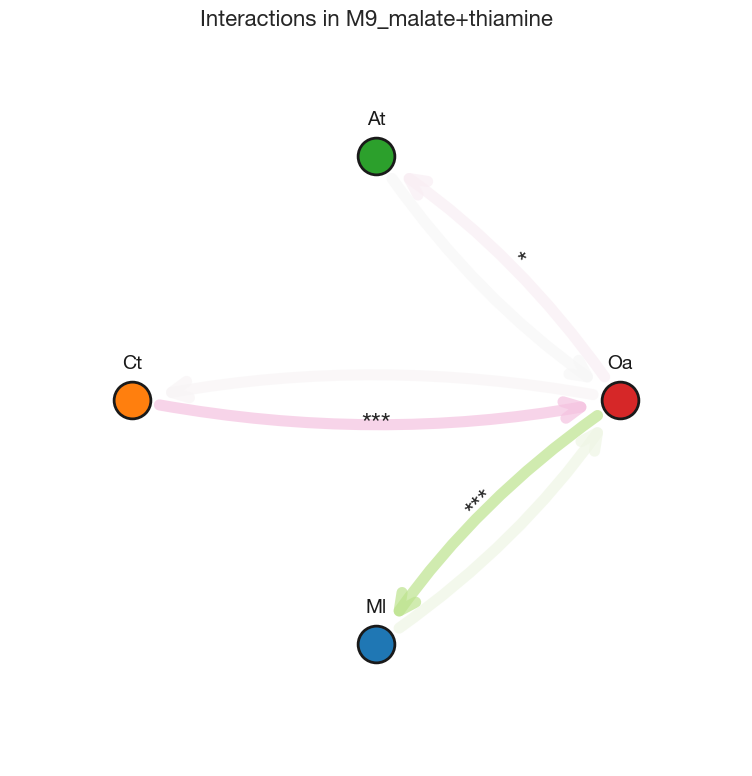

M9_malate+thiamine+biotin+cysteine+proline At Ml * -0.8880262405560676
M9_malate+thiamine+biotin+cysteine+proline Ct Ml * -1.069080919143299
M9_malate+thiamine+biotin+cysteine+proline Oa Ml * -0.7911162275480113


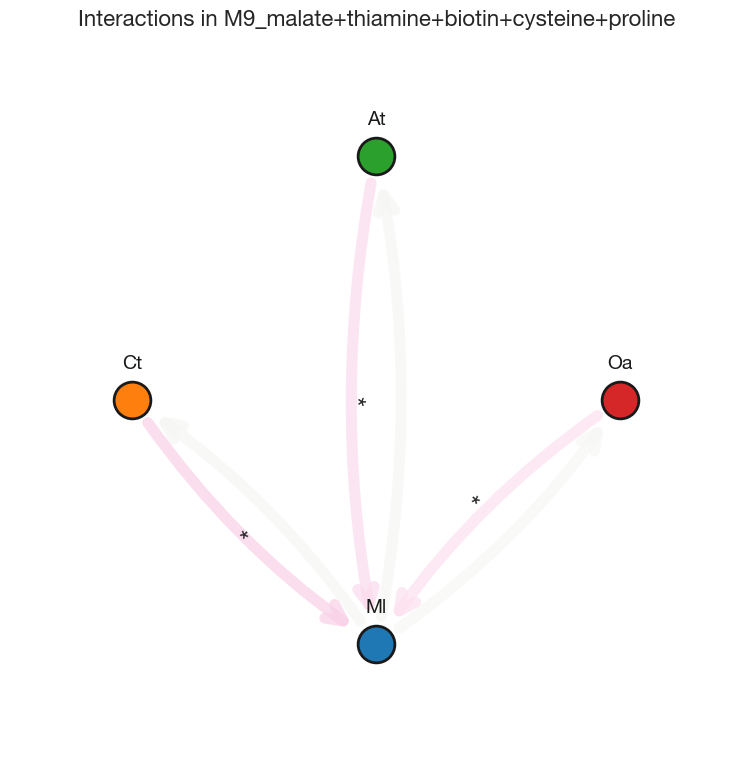

In [ ]:
import matplotlib.patches as mpatches

tab10 = sns.color_palette('tab10')
cs_palette = {'No CS': 'w', 'Malate': tab10[4],'Mannose': tab10[8], 'Isoleucine': tab10[6]}

# Example for a specific medium
# df_medium = interactions_df[interactions_df['Sh'] == 'Spent'].copy()

# Position species on a circle or grid
species_list = ['At', 'Ct', 'Ml', 'Oa']
n = len(species_list)
angles = np.linspace(-np.pi*1.5, 0.5*np.pi, n, endpoint=False)
species_pos = {species: (np.cos(angle), np.sin(angle)) 
               for species, angle in zip(species_list, angles)}

# Create plot



# Normalize interaction strength for coloring
norm = plt.Normalize(vmin=-4, 
                     vmax=4)
cmap = plt.cm.PiYG  # Red for negative, blue for positive
for i, medium in enumerate(interactions_df.Medium.unique()):
    df_medium = interactions_df.loc[interactions_df.Medium == medium]
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Draw arrows for each interaction
    for _, row in df_medium.iterrows():
        focal = row['Focal species']
        partner = row['Partner species']
        strength = row['log10 ratio']
        
        x1, y1 = species_pos[partner]
        x2, y2 = species_pos[focal]
        
        # Draw curved fish-hook style arrow
        arrow = mpatches.FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='->', 
            mutation_scale=30,
            linewidth=8,
            color=cmap(norm(strength)),
            alpha=0.7,
            connectionstyle="arc3,rad=0.1",  # Creates curved arrow (rad controls curvature)
            shrinkA=20, shrinkB=20
        )
        ax.add_patch(arrow)

        # Calculate position for annotation (along the curved path)
        # For arc3 with rad=0.1, approximate the midpoint of the curve
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        
        # Offset perpendicular to the line to follow the curve
        dx, dy = x2 - x1, y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        rad = 0.1  # Must match the rad in connectionstyle
        # Perpendicular offset for the annotation
        offset_x = -dy / length * rad #* length
        offset_y = dx / length * rad #* length
        
        # Calculate rotation angle of the arrow
        angle = np.degrees(np.arctan2(dy, dx))
        # Adjust angle to keep text readable (not upside down)
        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180
        
        signi = row['Significance annot']
        # Annotate with interaction score
        if signi:
            ax.text(mx - offset_x, my - offset_y, 
                    f'{signi}', 
                    ha='center', va='center',
                    rotation=angle, 
                    fontsize=20, 
                    fontweight='bold'
                    )
            print(medium, partner, focal, signi, strength)
            
        # ax.axvspan(-2,2, color = cs_palette[row['CS']], alpha = 0.1)
        # Or annotate with significance markers
        # if row['Corrected pvalue'] < 0.001:
        #     sig_marker = '***'
        # elif row['Corrected pvalue'] < 0.01:
        #     sig_marker = '**'
        # elif row['Corrected pvalue'] < 0.05:
        #     sig_marker = '*'
        # else:
        #     sig_marker = ''
        # 
        # if sig_marker:
        #     ax.text(mx + offset_x, my + offset_y, sig_marker, 
        #             ha='center', va='center', fontsize=12, fontweight='bold')



    # Draw species points
    for species, (x, y) in species_pos.items():
        ax.scatter(x, y, s=700, color=species_palette[species], 
                edgecolor='k', linewidth=2, zorder=10)
        ax.text(x, y+0.15, species, ha='center', va='center', 
            fontsize=14, fontweight='bold', color='k')
        
    # if i == 0:
        # Add colorbar
        
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Interactions in {medium}', fontsize=16)

    plt.tight_layout()
    plt.savefig(figure_folder / f'interaction_network_{medium}.pdf', bbox_inches='tight')
    plt.show()

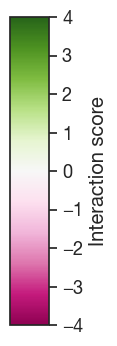

In [193]:
fig, ax = plt.subplots(1,1, figsize = (0.5,4))
# ax.axis('off')  # Hide the axis instead of removing it
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
cbar = plt.colorbar(sm, cax=ax, label='Interaction score')
plt.savefig(figure_folder / f'colorbar_only.pdf', bbox_inches='tight')
plt.show()


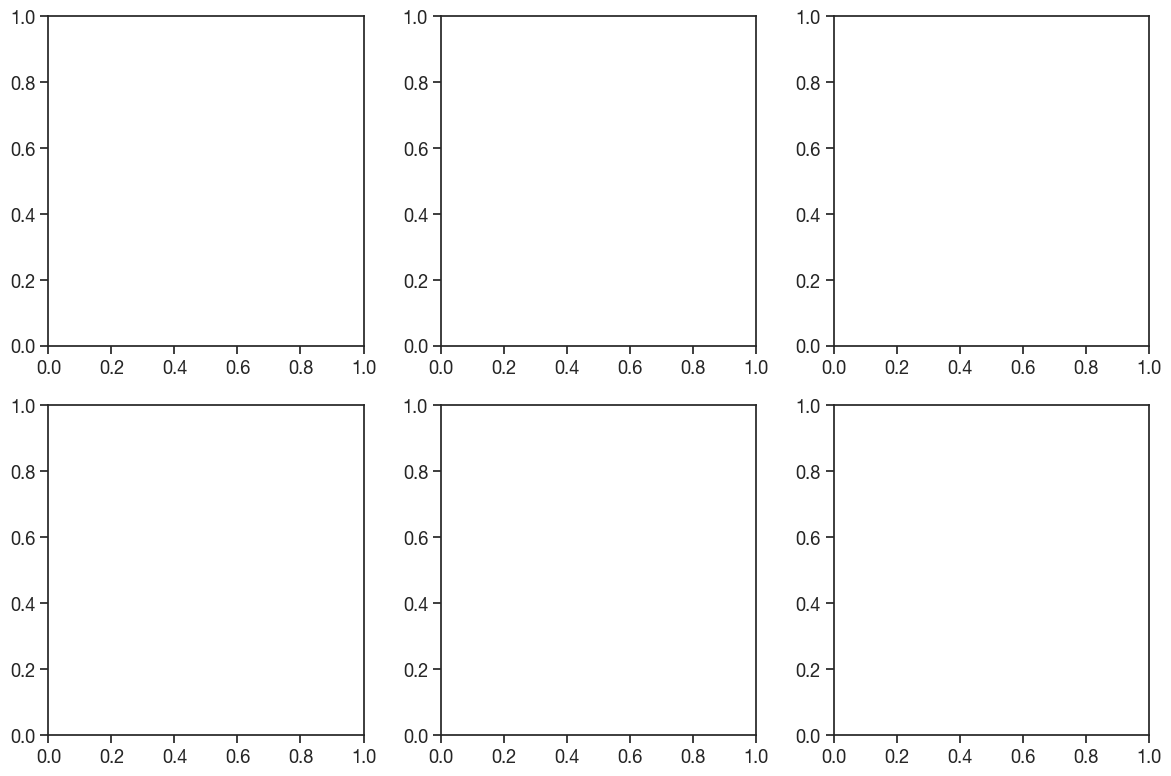

In [99]:
# Plot individual pairs
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (_, row) in enumerate(df_medium.head(6).iterrows()):
    ax = axes[idx]
    focal = row['Focal species']
    partner = row['Partner species']
    strength = row['log10 ratio']
    
    # Two points
    ax.scatter([0], [0], s=300, c=species_palette[partner], edgecolor='k', linewidth=2)
    ax.scatter([1], [0], s=300, c=species_palette[focal], edgecolor='k', linewidth=2)
    
    # Arrow
    arrow = mpatches.FancyArrowPatch(
        (0, 0), (1, 0),
        arrowstyle='->',
        mutation_scale=30,
        linewidth=3,
        color=cmap(norm(strength)),
        alpha=0.8
    )
    ax.add_patch(arrow)
    
    # Labels
    ax.text(0, -0.15, partner, ha='center', fontsize=12, fontweight='bold')
    ax.text(1, -0.15, focal, ha='center', fontsize=12, fontweight='bold')
    ax.text(0.5, 0.15, f'{strength:.2f}', ha='center', fontsize=10)
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 0.3)
    ax.axis('off')
    ax.set_title(f'{partner} → {focal}')

plt.tight_layout()
plt.show()

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77958/2048964825.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


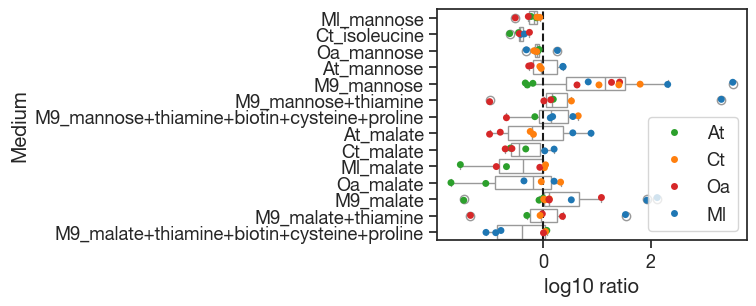

In [54]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', hue = 'Focal species', palette=species_palette, ax=ax)
sns.boxplot(data = interactions_df, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
# plt.savefig('Interactions mannose.pdf')

In [55]:
interactions_df.loc[interactions_df.isna().any(axis=1)]

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,Corrected pvalue,log10 pval,log10 adj. pval,Fresh,Significance,abs log10 ratio
66,At,Ct,Oa_malate,-1.720159,NaN,4.123855e-07,0.000013,-6.384697,-4.879547,Spent,True,1.720159
68,At,Ml,Oa_malate,-1.073021,NaN,2.096199e-04,0.001437,-3.678568,-2.842424,Spent,True,1.073021


# Heatmaps


In [56]:
interactions_df['Significance annot'] = ''
for i, row in interactions_df.iterrows():
    if 0.01 < row['Corrected pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['Corrected pvalue'] < 0.01:
        annot = '**'
    elif row['Corrected pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    interactions_df.at[i, 'Significance annot'] = annot
    

Ml_mannose
Ct_isoleucine
Oa_mannose
At_mannose
M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_malate
Ct_malate
Ml_malate
Oa_malate
M9_malate
M9_malate+thiamine
M9_malate+thiamine+biotin+cysteine+proline


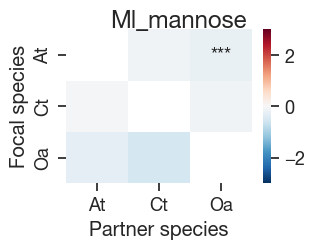

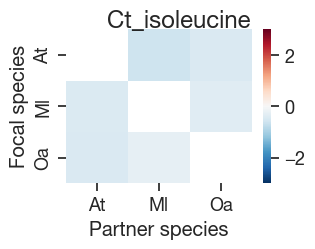

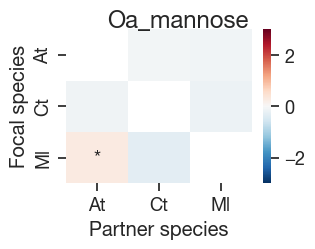

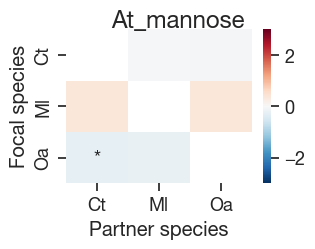

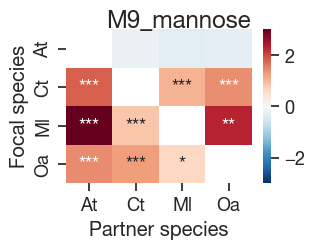

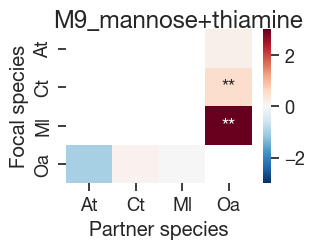

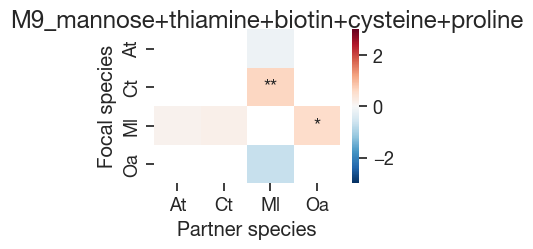

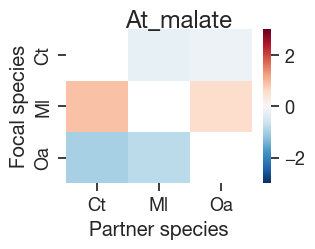

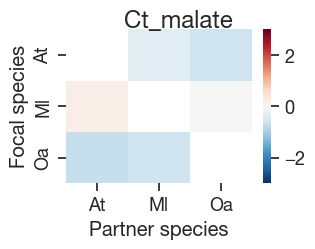

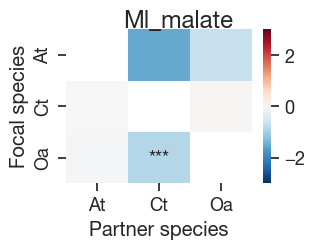

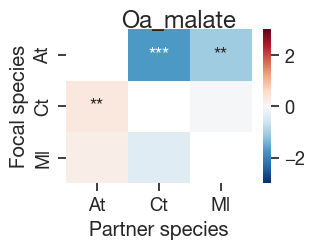

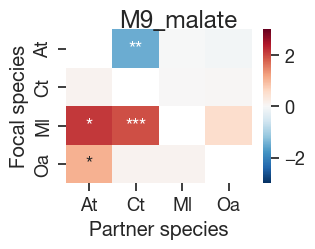

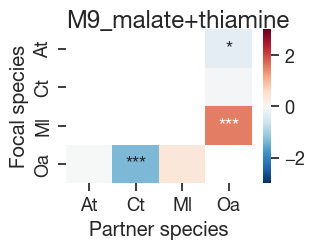

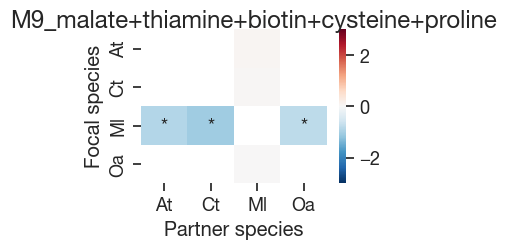

In [57]:
for medium in interactions_df.Medium.unique():
    print(medium)
    dfm = interactions_df.loc[interactions_df.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1, figsize = (3,2))
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')
    plt.savefig(figure_folder / f'interaction_heatmap_{medium}.pdf')

In [58]:
cfu_df = cfu_df_dict['spent_mannose2']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

NameError: name 'cfu_df_dict' is not defined

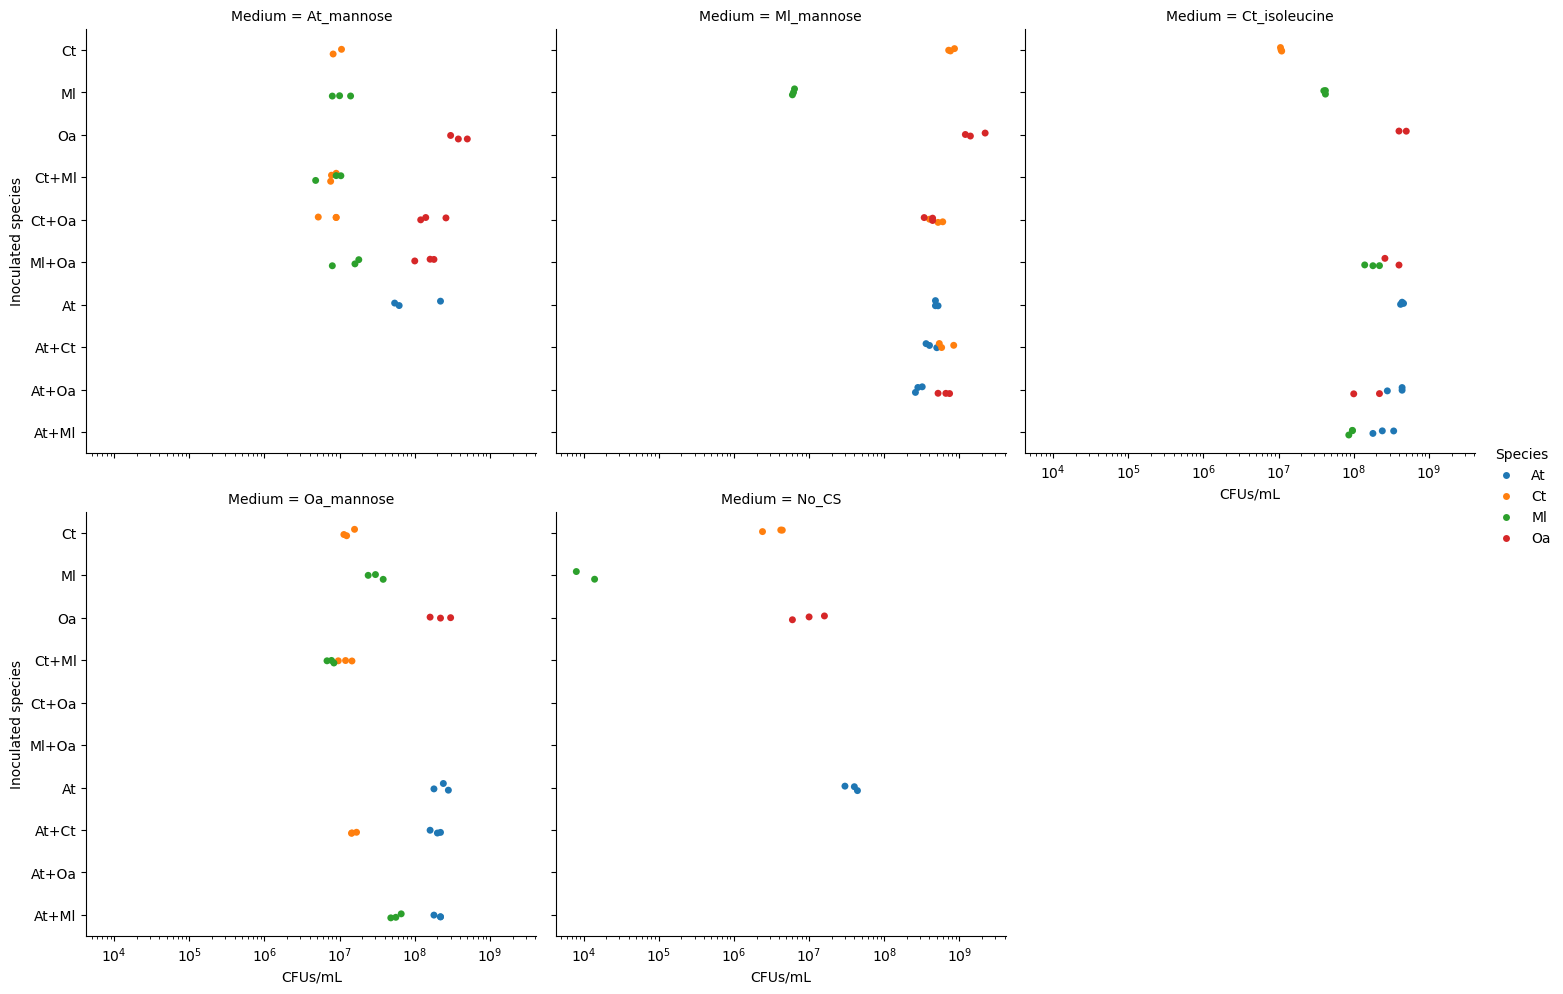

In [ ]:
cfu_df = cfu_df_dict['spent_mannose3']
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

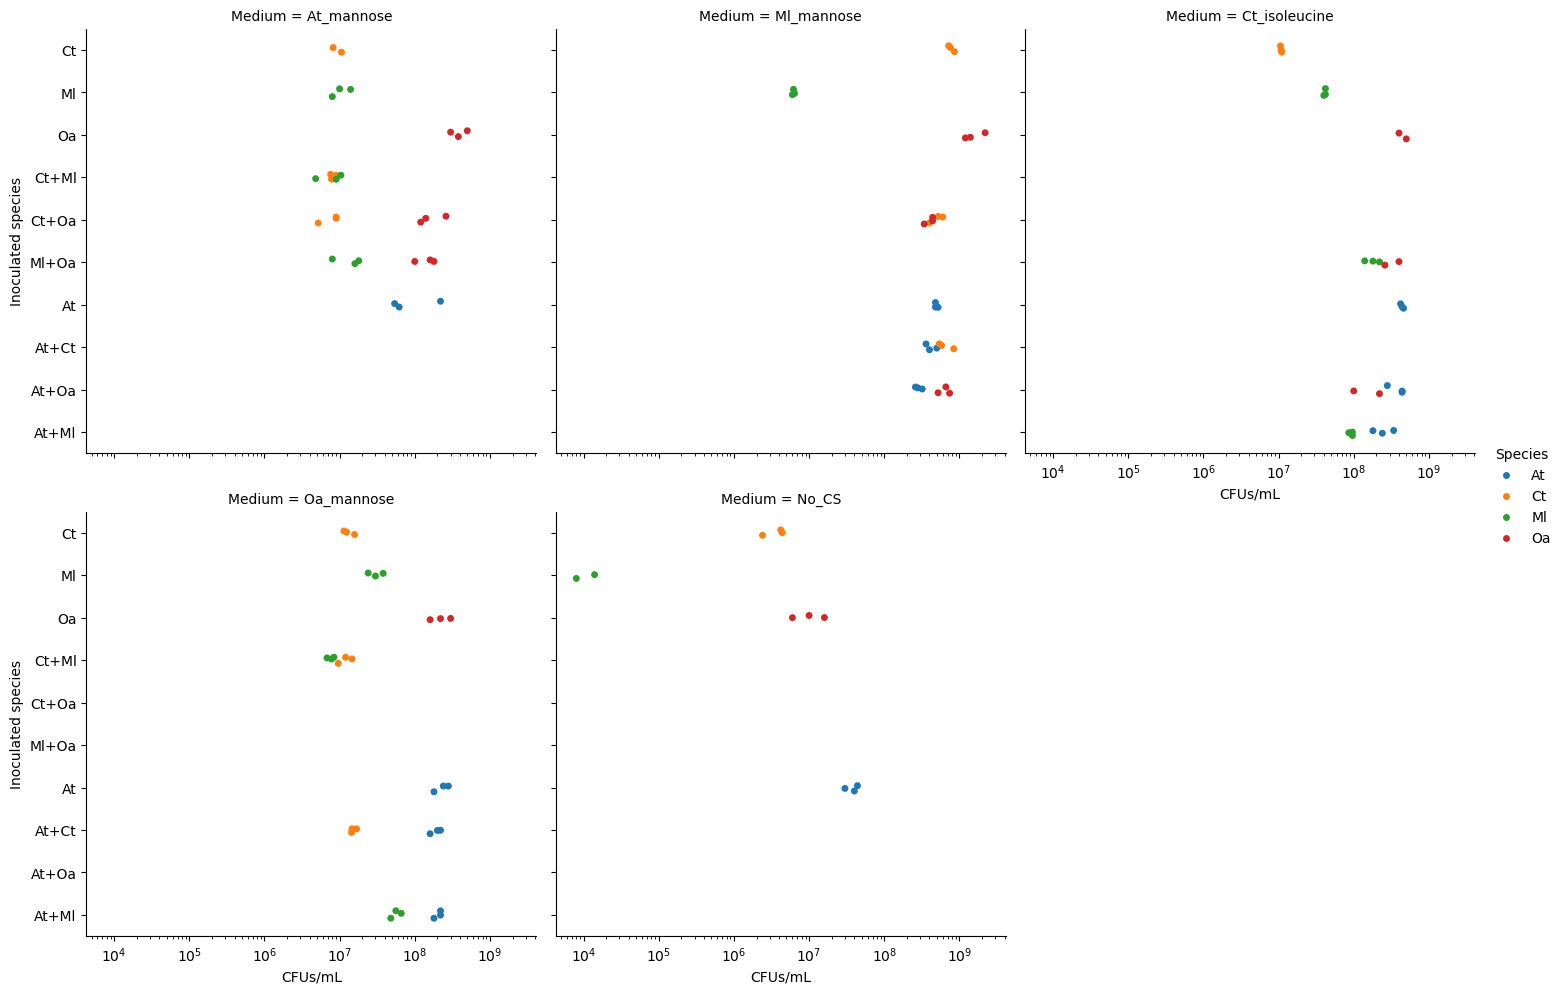

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'strip')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

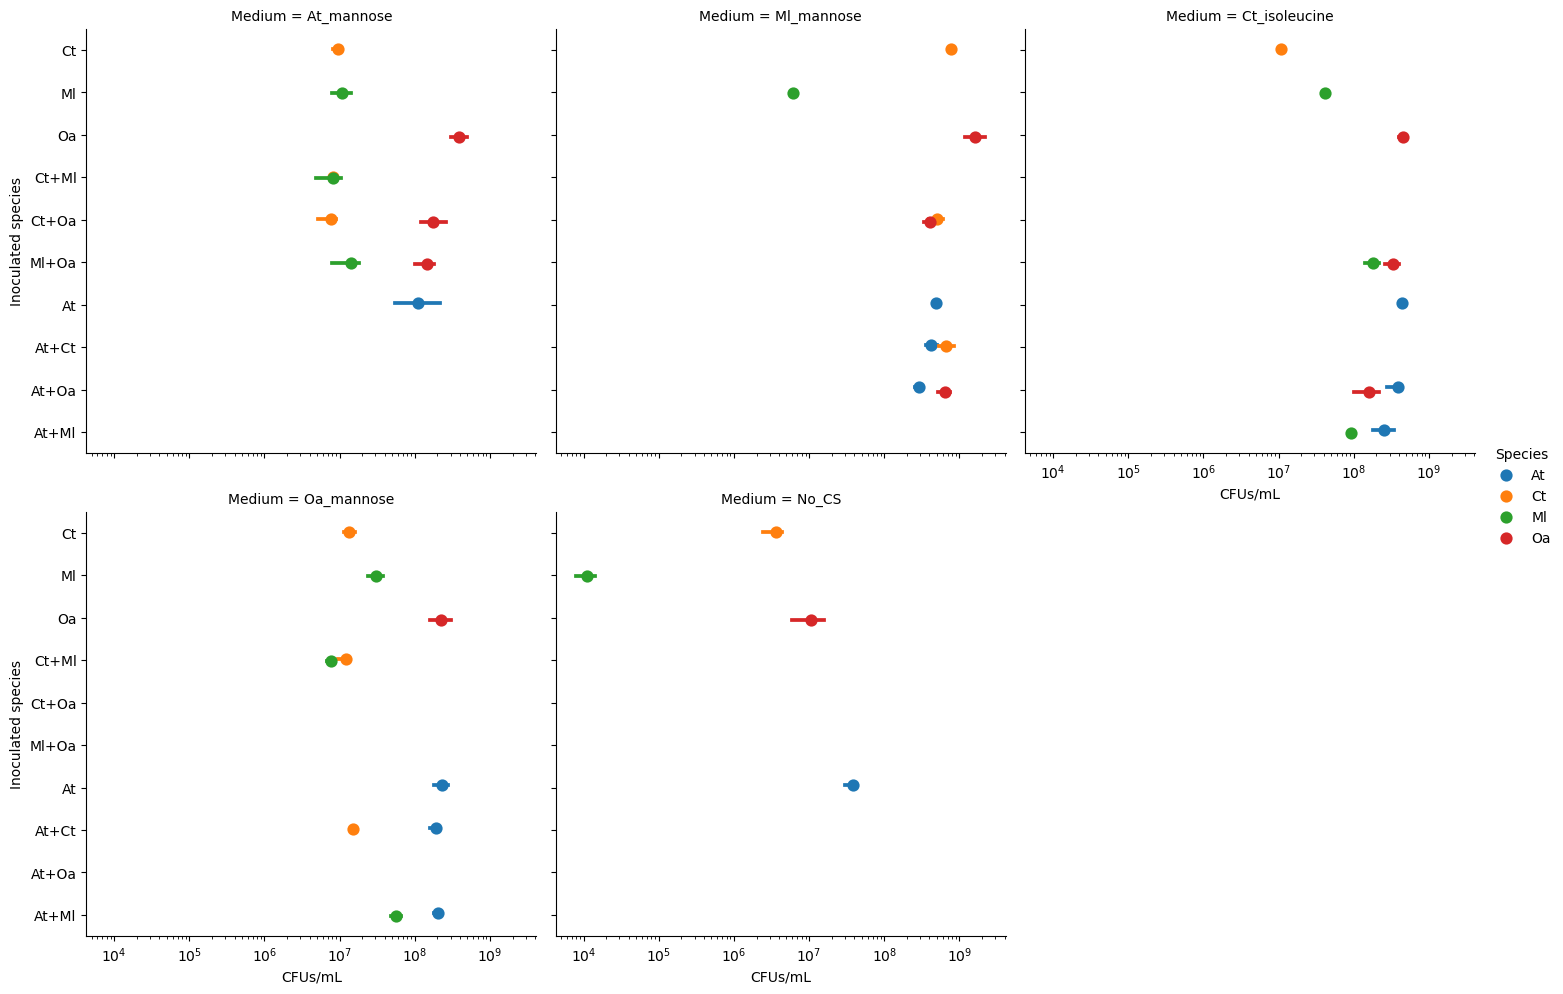

In [ ]:
idx = cfu_df.Plate!=0
sns.catplot(data = cfu_df.loc[idx], y= 'Inoculated species', x = 'CFUs/mL', hue = 'Species', col = 'Medium', col_wrap=3,  kind = 'point', dodge=True, markers="o", linestyle = 'None')#join=False removes lines between points, markers ensure points are dots, scale adjust the dots size
plt.xscale('log')
# plt.xlim(1e3, 1e11)
plt.show()

# Quantify interactions

In [ ]:
# Join spent mannose data
spent_mannose_cfu = pd.concat([cfu_df_dict['spent_mannose2'], cfu_df_dict['spent_mannose3']])
spent_mannose_cfu.reset_index(inplace=True, drop = True)

In [ ]:
spent_mannose_cfu.to_csv('cfus_spent_mannose.csv')

## Spent medium

In [ ]:
spent_mannose_cfu['Inoculated species'].astype('str')

0      nan
1      nan
2      nan
3      nan
4      nan
      ... 
715     Ml
716     Ml
717     Oa
718     Oa
719     Oa
Name: Inoculated species, Length: 720, dtype: object

In [ ]:
spent_mannose_cfu['Is coculture'] = spent_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in spent_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = spent_mannose_cfu.loc[spent_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
spent_mannose_isoleucine_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_isoleucine_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('isoleucine')]
spent_mannose_interactions = spent_mannose_isoleucine_interactions.loc[spent_mannose_isoleucine_interactions.Medium.str.contains('mannose')]

# Fresh mannose

In [ ]:
fresh_mannose_cfu = cfu_df_dict['fresh_mannose']
fresh_mannose_cfu['Is coculture'] = fresh_mannose_cfu['Inoculated species'].str.contains(r'\+')
four_species = ['At', 'Ct', 'Ml', 'Oa']
interactions = []
for medium in fresh_mannose_cfu.Medium.unique():
    if medium == 'No_CS':
        continue
    dfm = fresh_mannose_cfu.loc[fresh_mannose_cfu.Medium==medium]
    dfm_co = dfm.loc[dfm['Is coculture']==True]
    # dfm_mono = dfm.loc[dfm['Is coculture']!=True]
    coculture_pairs = dfm_co['Inoculated species'].unique()
    for pair in coculture_pairs:
        s1,s2 = pair.split('+')
        # Interaction of 2 on 1
        # Log response ratio
        s1_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s1)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s1), 'CFUs/mL'].dropna()
        s1_mono = ufloat(s1_growth_in_mono.mean(), s1_growth_in_mono.std())
        s1_co = ufloat(s1_growth_in_co.mean(), s1_growth_in_co.std())
        
        lrr_s1 = log10(s1_co/s1_mono)
        # lrr_s1 = np.log10(s1_growth_in_co.mean()/s1_growth_in_mono.mean())
        ttest_res1 = st.ttest_ind(s1_growth_in_mono, s1_growth_in_co)
        
        s2_growth_in_mono = dfm.loc[(dfm['Inoculated species']==s2)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        s2_growth_in_co   = dfm.loc[(dfm['Inoculated species']==pair)&(dfm.Species==s2), 'CFUs/mL'].dropna()
        
        # the uncertainty package estimates matches with how to in https://en.wikipedia.org/wiki/Propagation_of_uncertainty
        s2_mono = ufloat(s2_growth_in_mono.mean(), s2_growth_in_mono.std())
        s2_co   = ufloat(s2_growth_in_co.mean(), s2_growth_in_co.std())
        
        lrr_s2 = log10(s2_co/s2_mono)
        # lrr_s2 = np.log10(s2_growth_in_co.mean()/s2_growth_in_mono.mean())
        ttest_res2 = st.ttest_ind(s2_growth_in_mono, s2_growth_in_co)

        # rd_s1 = (s1_growth_in_co.mean()-s1_growth_in_mono.mean())/s2_growth_in_co.mean()
        # rd_s2 = (s2_growth_in_co.mean()-s2_growth_in_mono.mean())/s1_growth_in_co.mean()

        interactions.append([s1, s2, medium, lrr_s1.nominal_value, lrr_s1.std_dev, ttest_res1.pvalue])
        interactions.append([s2, s1, medium, lrr_s2.nominal_value, lrr_s2.std_dev, ttest_res2.pvalue])
fresh_mannose_interactions = pd.DataFrame(interactions, columns = ['Focal species', 'Partner species', 'Medium', 
                                                                   'log10 ratio','log10 ratio std', 'T-test pvalue'])

In [ ]:
spent_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,Ct,Ml,At_mannose,-0.042771,0.094802,0.318843
1,Ml,Ct,At_mannose,0.360580,0.428275,0.181713
2,Ct,Oa,At_mannose,-0.067773,0.116755,0.201653
3,Oa,Ct,At_mannose,-0.274574,0.240609,0.006504
4,Ml,Oa,At_mannose,0.363594,0.329930,0.085762
5,Oa,Ml,At_mannose,-0.231527,0.253162,0.022293
6,At,Ct,Ml_mannose,-0.130848,0.149839,0.146230
7,Ct,At,Ml_mannose,-0.070200,0.192876,0.419410
8,At,Oa,Ml_mannose,-0.230742,0.043686,0.000121
9,Oa,At,Ml_mannose,-0.282281,0.189848,0.043636


In [ ]:
fresh_mannose_interactions

,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue
0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01
1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05
2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02
3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06
4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02
5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07
6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04
7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05
8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06
9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06


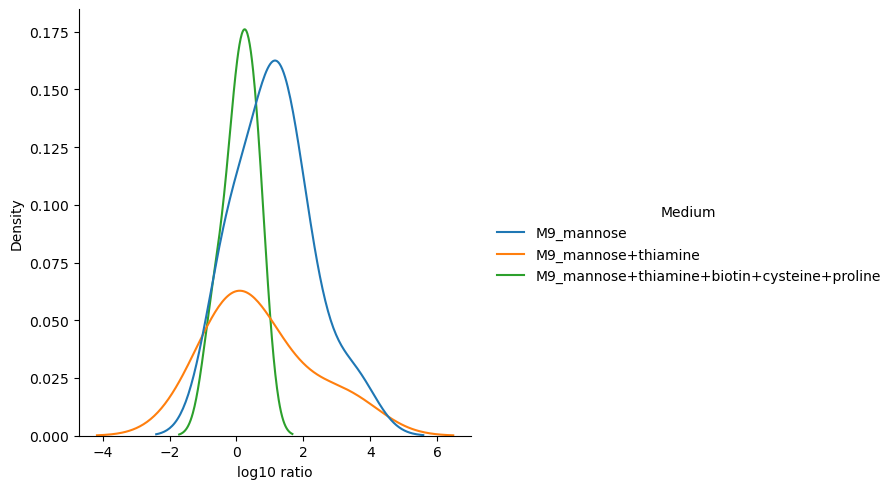

In [ ]:
ax = sns.displot(data = fresh_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

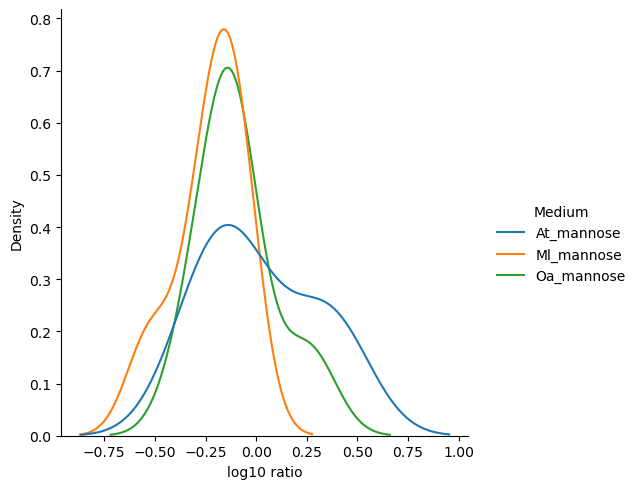

In [ ]:
ax = sns.displot(data = spent_mannose_interactions, x = 'log10 ratio', hue = 'Medium', kind = 'kde')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [ ]:
all_interactions = pd.concat([fresh_mannose_interactions, spent_mannose_interactions]).reset_index()

In [ ]:
all_interactions['log10 pval'] = np.log10(all_interactions['T-test pvalue'])

<Axes: xlabel='log10 ratio', ylabel='Medium'>

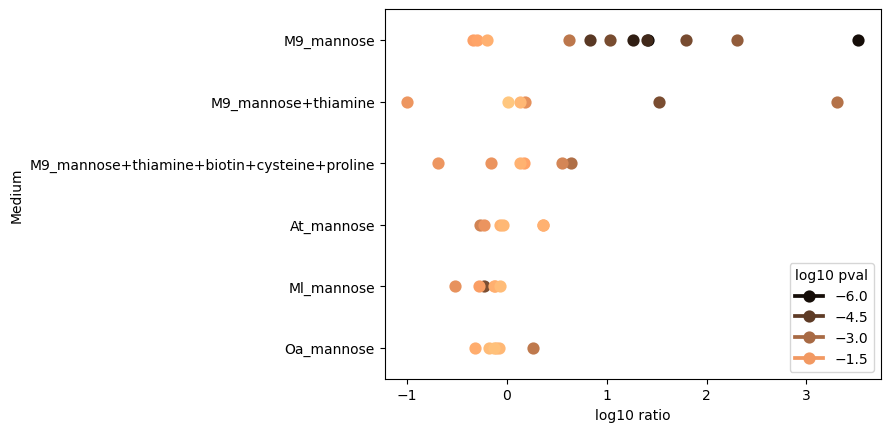

In [ ]:
sns.pointplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_77193/3074553416.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


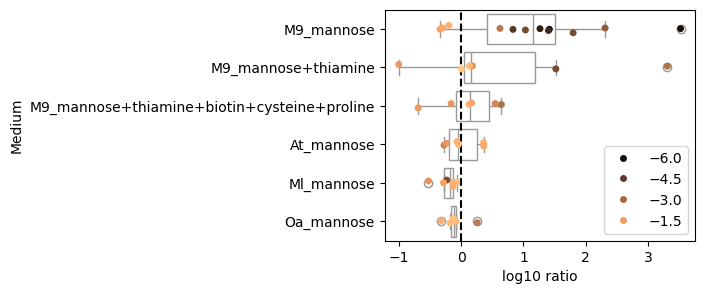

In [ ]:
fig, ax = plt.subplots(1, figsize = (4,3))
sns.stripplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', hue = 'log10 pval', palette='copper', ax=ax)
sns.boxplot(data = all_interactions, x = 'log10 ratio', y = 'Medium', color = 'w')
ax.axvline(0, ls = '--', c = 'k', zorder = 2)
plt.tight_layout()
plt.savefig('Interactions mannose.pdf')

## Heatmaps

In [ ]:
all_interactions['Significance annot'] = ''
for i, row in all_interactions.iterrows():
    if 0.01 < row['T-test pvalue'] < 0.05:
        annot = '*'
    elif 0.001 < row['T-test pvalue'] < 0.01:
        annot = '**'
    elif row['T-test pvalue'] < 0.001:
        annot = '***'
    else:
        annot = ''
    all_interactions.at[i, 'Significance annot'] = annot
    

In [ ]:
all_interactions

,index,Focal species,Partner species,Medium,log10 ratio,log10 ratio std,T-test pvalue,log10 pval,Significance annot
0,0,At,Ct,M9_mannose,-0.197025,0.204718,1.629299e-01,-0.787999,
1,1,Ct,At,M9_mannose,1.796470,0.178920,9.824423e-05,-4.007693,***
2,2,At,Ml,M9_mannose,-0.338354,0.198920,5.356951e-02,-1.271082,
3,3,Ml,At,M9_mannose,3.518984,0.398043,1.043443e-06,-5.981531,***
4,4,At,Oa,M9_mannose,-0.299330,0.201307,7.041765e-02,-1.152318,
5,5,Oa,At,M9_mannose,1.414675,0.051844,3.746039e-07,-6.426428,***
6,6,Ct,Ml,M9_mannose,1.031340,0.175135,1.050370e-04,-3.978658,***
7,7,Ml,Ct,M9_mannose,0.831596,0.396524,2.506001e-05,-4.601019,***
8,8,Ct,Oa,M9_mannose,1.400884,0.163425,8.129531e-06,-5.089934,***
9,9,Oa,Ct,M9_mannose,1.264649,0.063461,3.589759e-06,-5.444935,***


M9_mannose
M9_mannose+thiamine
M9_mannose+thiamine+biotin+cysteine+proline
At_mannose
Ml_mannose
Oa_mannose


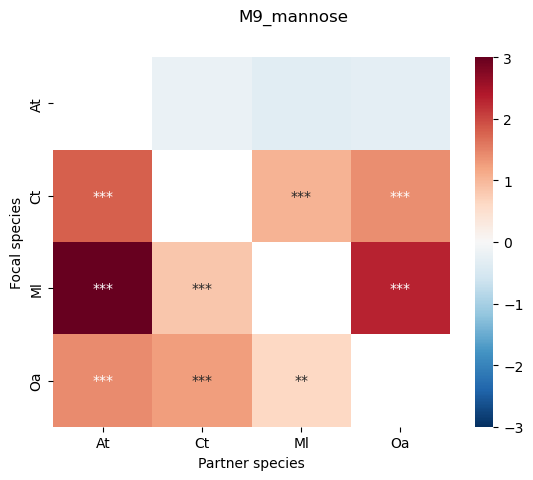

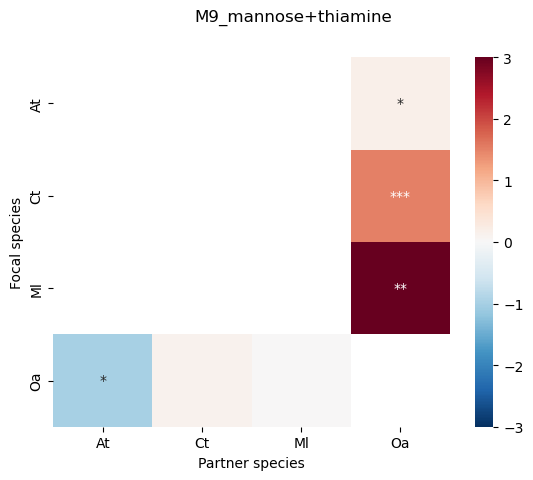

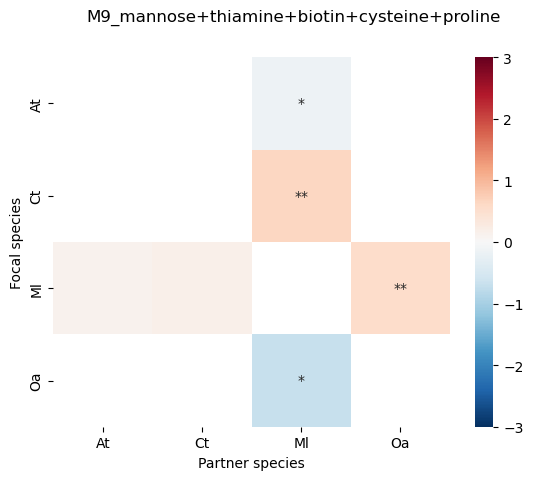

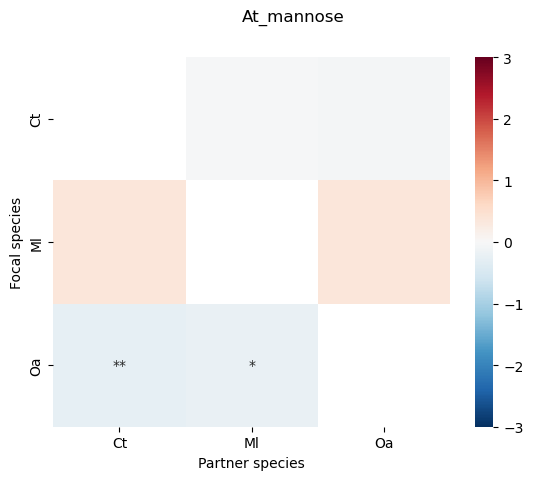

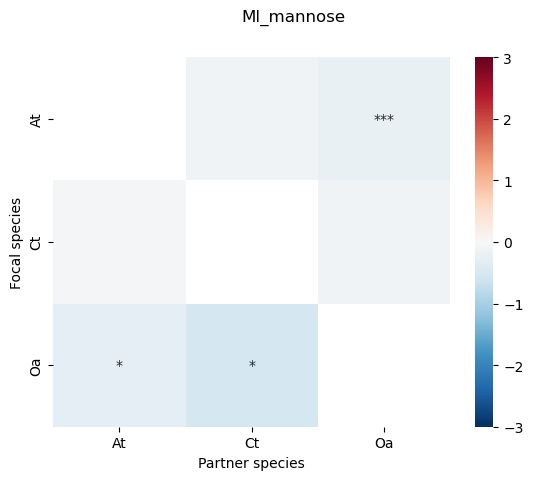

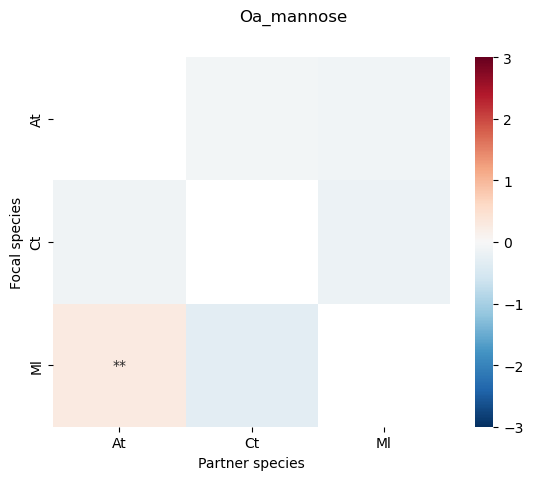

In [ ]:
for medium in all_interactions.Medium.unique():
    print(medium)
    dfm = all_interactions.loc[all_interactions.Medium==medium]
    dfmp = dfm.pivot(columns = 'Partner species', index = 'Focal species')
    fig, ax = plt.subplots(1)
    fig.suptitle(medium)
    sns.heatmap(dfmp['log10 ratio'], cmap = 'RdBu_r', ax = ax, vmin = -3, vmax = 3, annot = dfmp['Significance annot'], fmt = '')